# EEG Seizure Detection using Deep Neural Networks

This project demonstrates the effective use of a Long Short-Term Memory (LSTM) and Transformer
to accurately detect epileptic seizures from raw EEG signals, utilizing the UCI Epileptic Seizure
Recognition dataset.

## Long Short-Term Memory (LSTM)

In [21]:
import warnings
warnings.filterwarnings('ignore')

import kagglehub
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow as tf
import requests
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
import seaborn

## Download data
Download the UCI Epileptic Seizure Recognition Dataset

In [22]:
path = kagglehub.dataset_download("harunshimanto/epileptic-seizure-recognition")
# Locate the CSV file in the downloaded directory
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
full_path = os.path.join(path, csv_file)
print(f"Loading data from: {full_path}")
df = pd.read_csv(full_path)

Loading data from: /home/park/.cache/kagglehub/datasets/harunshimanto/epileptic-seizure-recognition/versions/2/Epileptic Seizure Recognition.csv


In [23]:
df.head()
# y values in the UCI dataset: 1 = Seizure, 2 through 5 = Normal/resting states

,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


In [24]:
# Cleaning the data
X_raw = df.iloc[:,1:-1].values
y_raw = df['y'].values
X = X_raw.reshape(X_raw.shape[0], X_raw.shape[1], 1)
y = np.where(y_raw == 1, 1, 0)

# Split 1: Hold out 15% of the data exclusively for the final Test set.
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
# Split 2: Divide the remaining 85% into Training and Validation sets.
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.15, random_state=42, stratify=y_temp)
print(f"Training set:{X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set:8308 samples
Validation set: 1467 samples
Test set: 1725 samples


## Handling Class Imbalance (Training Set Only)
Because seizures are rare, compute_class_weight compensates for the data imbalance by penalizing
the model more when it misses a Seizure.

In [25]:
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(weights))
print(f"Computed Class Weights: {class_weights}")

Computed Class Weights: {0: np.float64(0.6250376166114956), 1: np.float64(2.4993983152827917)}


## LSTM Model Architecture

(1) The Input: The model receives raw EEG data (a sequence of 178 continuous time steps
corresponding to 1 second).  

(2) The First LSTM Layer (64 units): This is the primary feature extractor. It reads the EEG
signal step-by-step. Because we set return_sequences=True, it outputs a complex sequence
of patterns for every single time step, capturing the immediate, short-term fluctuations in the
brainwaves.

(3) Regularization (Dropout & Batch Normalization): To prevent the model from just memorizing
the training data, Dropout randomly ignores 30% of the connections during training. Batch
Normalization then scales the signals to keep the internal math stable and speed up learning.

(4) The Second LSTM Layer (32 units): This layer takes the complex sequence of patterns found
by the first layer and synthesizes them. Because return_sequences=False, it stops looking at
individual steps and outputs a single, final 32-number summary of the entire 1-second event.

(5) The Output Layer (Dense): A single neuron uses a sigmoid activation function to squash that
final summary into a final probability between 0.0 and 1.0 (e.g., a 0.85 means the model is
85% confident the signal contains a seizure).

In [26]:
model = Sequential([
    Input(shape=(X.shape[1], X.shape[2])),
    LSTM(64, return_sequences=True),
    # Dropout randomly turns off 30% of neurons during training to prevent overfitting (memorizing the data).
    Dropout(0.3),
    # BatchNormalization stabilizes and speeds up training by keeping neuron activations scaled correctly.
    BatchNormalization(), # Second LSTM Layer:
    # 'return_sequences=False' (the default) because the next layer is a standard Dense layer.
    # It only outputs the final summarized context of the entire 178-step sequence.
    LSTM(32, return_sequences=False),
    Dropout(0.3),
    BatchNormalization(),
    # Output Layer:
    # A single neuron with a 'sigmoid' activation squashes the output into a probability between 0.0 and 1.0.
    Dense(1, activation='sigmoid')
    ])
model.compile(optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

## Training with Validation Data

In [27]:
print("\nStarting model training...")
history = model.fit(X_train, y_train,epochs=15,
    # Number of times the model will see the entire training dataset
    batch_size=32, # The model updates its weights after processing 32 samples at a time
    validation_data=(X_val, y_val), # Checks performance on unseen validation data after every epoch
    class_weight=class_weights, # Applies our calculated penalty weights for the minority class
    verbose=1)


Starting model training...
Epoch 1/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8607 - auc: 0.9370 - loss: 0.3258 - val_accuracy: 0.9100 - val_auc: 0.9559 - val_loss: 0.2287
Epoch 2/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9333 - auc: 0.9707 - loss: 0.2111 - val_accuracy: 0.9605 - val_auc: 0.9797 - val_loss: 0.1384
Epoch 3/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9417 - auc: 0.9793 - loss: 0.1740 - val_accuracy: 0.9366 - val_auc: 0.9865 - val_loss: 0.1782
Epoch 4/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9467 - auc: 0.9810 - loss: 0.1645 - val_accuracy: 0.9441 - val_auc: 0.9817 - val_loss: 0.1984
Epoch 5/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9590 - auc: 0.9884 - loss: 0.1277 - val_accuracy: 0.9530 - val_auc: 0.9891 - val_loss: 0.1444
Epoch 6/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9643 - auc: 0.9897 - loss: 0.1194 - val_accuracy: 0.9639 - val_auc: 0.9866 - val_loss: 0.1364
Epoch 7/15


## Evaluation (Test Set)

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

Classification Report (Test Data):
              precision    recall  f1-score   support

  Normal (0)       0.99      0.99      0.99      1380
 Seizure (1)       0.96      0.95      0.96       345

    accuracy                           0.98      1725
   macro avg       0.97      0.97      0.97      1725
weighted avg       0.98      0.98      0.98      1725



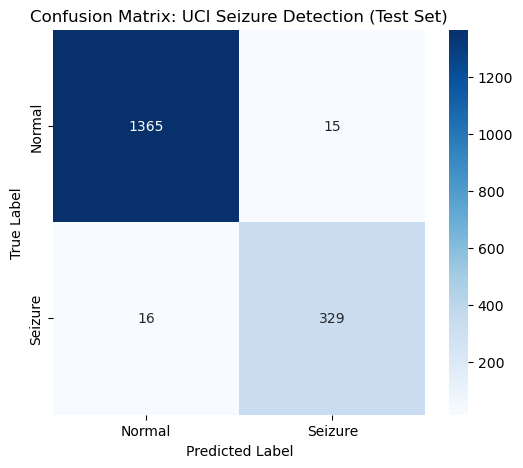

In [28]:
# Ask the trained model to predict probabilities for the unseen Test set
y_pred_prob = model.predict(X_test) 
# Convert the raw probabilities into hard predictions (0 or 1) using a 50% threshold
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
print("\nClassification Report (Test Data):")

print(classification_report(y_test, y_pred, target_names=['Normal (0)','Seizure (1)']))
# --- Plot 1: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
# Use seaborn to create a visual heatmap of the True Positives, False Positives, etc.
seaborn.heatmap(cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Normal', 'Seizure'],
    yticklabels=['Normal', 'Seizure'])
plt.title('Confusion Matrix: UCI Seizure Detection (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Transformer

In [29]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, MultiHeadAttention, Add, GlobalAveragePooling1D, Embedding

## Model Architecture

In [30]:
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.0):
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    x = Dropout(dropout)(x)
    res = Add()([x, inputs])
    res = LayerNormalization(epsilon=1e-6)(res)
    x = Dense(ff_dim, activation="relu")(res)
    x = Dropout(dropout)(x)
    x = Dense(inputs.shape[-1])(x)
    x = Add()([x, res])
    return LayerNormalization(epsilon=1e-6)(x)
    # Rebuild the model with Positional Encoding
    
input_shape = (X.shape[1], X.shape[2])
inputs = Input(shape=input_shape)
# Project the EEG amplitude value into a 64-dimensional space
x = Dense(64)(inputs)
# Generate learned positional embeddings
positions = tf.range(start=0, limit=X.shape[1], delta=1)
position_embeddings = Embedding(input_dim=X.shape[1], output_dim=64)(positions)
# Inject the concept of time by adding the positions directly to the EEG data
x = x + position_embeddings
# Pass the time-aware data into the Transformer block
x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=64, dropout=0.3)
# Compress the 3D sequence data down to a 2D array
x = GlobalAveragePooling1D(data_format="channels_last")(x)
# Final classification layers
x = Dense(32, activation="relu")(x)
x = Dropout(0.3)(x)
outputs = Dense(1, activation="sigmoid")(x)
model = Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

## Training

In [31]:
history = model.fit(
    X_train, y_train,
    epochs=15, # Number of times the model will see the entire training dataset
    batch_size=32, # The model updates its weights after processing 32 samples at a time
    validation_data=(X_val, y_val), # Checks performance on unseen validation data after every epoch
    class_weight=class_weights, # Applies our calculated penalty weights for the minority class
    verbose=1
    )

Epoch 1/15


I0000 00:00:1773840119.515298   25933 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_96529__.53


234/260 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7076 - auc: 0.7880 - loss: 0.5484

I0000 00:00:1773840123.201641   25934 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_96529__.53


260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7082 - auc: 0.7909 - loss: 0.5456

I0000 00:00:1773840126.049139   25935 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_98459__.20
I0000 00:00:1773840126.705336   25935 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_98459__.20


260/260 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.7126 - auc: 0.8188 - loss: 0.5204 - val_accuracy: 0.8766 - val_auc: 0.9218 - val_loss: 0.3484
Epoch 2/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9038 - auc: 0.9682 - loss: 0.2278 - val_accuracy: 0.9502 - val_auc: 0.9870 - val_loss: 0.1288
Epoch 3/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9342 - auc: 0.9826 - loss: 0.1626 - val_accuracy: 0.9482 - val_auc: 0.9858 - val_loss: 0.1368
Epoch 4/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9402 - auc: 0.9854 - loss: 0.1484 - val_accuracy: 0.9366 - val_auc: 0.9878 - val_loss: 0.1398
Epoch 5/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9443 - auc: 0.9866 - loss: 0.1399 - val_accuracy: 0.9468 - val_auc: 0.9830 - val_loss: 0.1356
Epoch 6/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9407 - auc: 0.9861 - loss: 0.1439 - val_accuracy: 0.9591 - val_auc: 0.9887 - val_loss: 0.1117
Epoch 7/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/ste

## Evaluation

I0000 00:00:1773840187.080698   25928 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_122011__.8


 1/54 ━━━━━━━━━━━━━━━━━━━━ 33s 629ms/step

I0000 00:00:1773840187.701765   25931 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_122313__.8
I0000 00:00:1773840188.578055   33024 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_13', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1773840188.749957   33018 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_5', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1773840189.024441   33016 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4', 48 bytes spill stores, 48 bytes spill loads



54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step

Classification Report (Test Data):
              precision    recall  f1-score   support

  Normal (0)       0.99      0.96      0.97      1380
 Seizure (1)       0.85      0.95      0.90       345

    accuracy                           0.96      1725
   macro avg       0.92      0.96      0.94      1725
weighted avg       0.96      0.96      0.96      1725



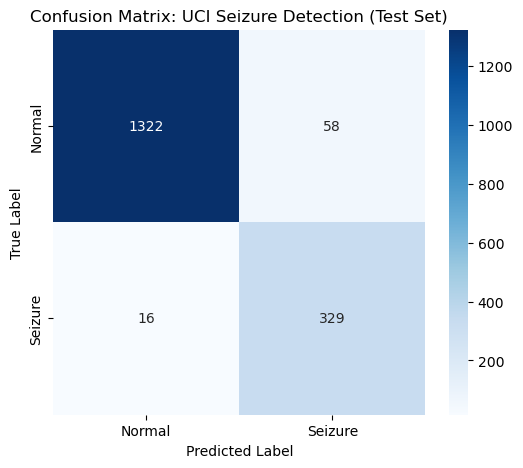

In [32]:
# Ask the trained model to predict probabilities for the unseen Test set
y_pred_prob = model.predict(X_test) 
# Convert the raw probabilities into hard predictions (0 or 1) using a 50% threshold
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
print("\nClassification Report (Test Data):")

print(classification_report(y_test, y_pred, target_names=['Normal (0)','Seizure (1)']))
# --- Plot 1: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
# Use seaborn to create a visual heatmap of the True Positives, False Positives, etc.
seaborn.heatmap(cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Normal', 'Seizure'],
    yticklabels=['Normal', 'Seizure'])
plt.title('Confusion Matrix: UCI Seizure Detection (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Convolutional Neural Networks (CNN)

CNN uses Conv1D layers to slide small mathematical windows across the raw signal. This allows it to automatically detect specific,
localized physical shapes like the sharp spikes typical of a seizure. As it scans, MaxPooling1D layers
compress the data by discarding weaker signals and keeping only the strongest features, rapidly
streamlining the information before the final classification layer makes its prediction.

In [34]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, BatchNormalization, GlobalAveragePooling1D

## Model Architecture

In [36]:
model = Sequential([
    # Input layer to define the shape of the incoming EEG epoch
    Input(shape=(X.shape[1], X.shape[2])),
    # --- First Convolutional Block ---
    # The Conv1D layer slides a window (kernel_size=5) across the sequence to extract 32 different local wave features (filters)
    Conv1D(filters=32, kernel_size=5, activation='relu'),
    BatchNormalization(), 
    # MaxPooling reduces the length of the sequence by half, keeping only the strongest signals
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    # --- Second Convolutional Block ---
    # Now it looks for 64 more complex, combined patterns using a smaller window
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    # --- Classification Head ---
    # GlobalAveragePooling1D flattens the remaining sequence into a single 1D array
    GlobalAveragePooling1D(),
    # A standard dense layer to process the extracted features
    Dense(32, activation='relu'),
    Dropout(0.3),
    # Final output layer for the binary "Normal" vs "Seizure" prediction
    Dense(1, activation='sigmoid')
    ])

# Compile the model exactly as we did for the LSTM and Transformer
model.compile(optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 174, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 174, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 87, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 87, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 85, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 85, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 42, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 42, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,897 (34.75 KB)

 Trainable params: 8,705 (34.00 KB)

 Non-trainable params: 192 (768.00 B)

## Training

In [37]:
history = model.fit(
    X_train, y_train,
    epochs=15, # Number of times the model will see the entire training dataset
    batch_size=32, # The model updates its weights after processing 32 samples at a time
    validation_data=(X_val, y_val), # Checks performance on unseen validation data after every epoch
    class_weight=class_weights, # Applies our calculated penalty weights for the minority class
    verbose=1)

Epoch 1/15


I0000 00:00:1773840564.079889   25928 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_125874__.49


206/260 ━━━━━━━━━━━━━━━━━━━━ 0s 739us/step - accuracy: 0.8576 - auc: 0.9483 - loss: 0.2833

I0000 00:00:1773840566.284220   25928 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_125874__.49


260/260 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9203 - auc: 0.9771 - loss: 0.1983 - val_accuracy: 0.9346 - val_auc: 0.9877 - val_loss: 0.1726
Epoch 2/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 954us/step - accuracy: 0.9421 - auc: 0.9869 - loss: 0.1464 - val_accuracy: 0.9448 - val_auc: 0.9886 - val_loss: 0.1319
Epoch 3/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 939us/step - accuracy: 0.9446 - auc: 0.9887 - loss: 0.1338 - val_accuracy: 0.9591 - val_auc: 0.9915 - val_loss: 0.1072
Epoch 4/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 969us/step - accuracy: 0.9452 - auc: 0.9891 - loss: 0.1303 - val_accuracy: 0.9400 - val_auc: 0.9932 - val_loss: 0.1296
Epoch 5/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 949us/step - accuracy: 0.9514 - auc: 0.9921 - loss: 0.1142 - val_accuracy: 0.9707 - val_auc: 0.9939 - val_loss: 0.0805
Epoch 6/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 948us/step - accuracy: 0.9568 - auc: 0.9918 - loss: 0.1133 - val_accuracy: 0.9652 - val_auc: 0.9951 - val_loss: 0.0867
Epoch 7/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 

## Evaluation

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

Classification Report (Test Data):
              precision    recall  f1-score   support

  Normal (0)       0.99      0.98      0.99      1380
 Seizure (1)       0.92      0.97      0.95       345

    accuracy                           0.98      1725
   macro avg       0.96      0.98      0.97      1725
weighted avg       0.98      0.98      0.98      1725



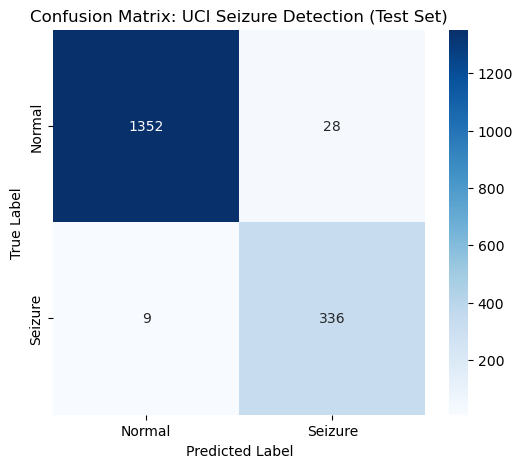

In [38]:
# Ask the trained model to predict probabilities for the unseen Test set
y_pred_prob = model.predict(X_test) 
# Convert the raw probabilities into hard predictions (0 or 1) using a 50% threshold
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
print("\nClassification Report (Test Data):")

print(classification_report(y_test, y_pred, target_names=['Normal (0)','Seizure (1)']))
# --- Plot 1: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
# Use seaborn to create a visual heatmap of the True Positives, False Positives, etc.
seaborn.heatmap(cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Normal', 'Seizure'],
    yticklabels=['Normal', 'Seizure'])
plt.title('Confusion Matrix: UCI Seizure Detection (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Summary

## Long Short-Term Memory (LSTM)
An LSTM reads data in a strict chronological order, one step at a time. It maintains an internal
hidden state, acting as a memory that updates as new information arrives. It uses mathematical
gates to decide what past information is worth keeping and what should be forgotten. This makes it
excellent for understanding the unfolding “story” of a sequence, but it can be slow to train because
it cannot process future steps until past steps are complete.

## Transformers
A Transformer completely abandons step-by-step processing and ingests the entire sequence of
data all at once. It relies on a mechanism called Multi-Head Attention, which mathematically
calculates how strongly every single data point relates to every other data point, regardless of how
far apart they are. Because it processes everything simultaneously, it is incredibly fast and highly
effective at finding complex, long-distance relationships, but it requires added positional tags just
to understand the original chronological order of the data.

## Convolutional Neural Networks (CNN)
A CNN acts as an aggressive pattern scanner. Instead of looking at the overall sequence or distant
relationships, it slides small mathematical windows, called filters, across the data. These filters
are designed to automatically detect specific, localized physical shapes, such as a sharp spike in a
signal or an edge in an image. It does not care where the pattern occurs or what order it appears
in; it simply flags when a target shape is found.